# Exercice 1 — Découvrir un environnement de Reinforcement Learning

## Objectif

Ce premier exercice met en place le vocabulaire et la boucle d'interaction qui
seront réutilisés dans les exercices suivants.

1. Inspecter les espaces d'observation et d'action de **CartPole-v1**.
2. Mesurer une politique aléatoire pour obtenir une **baseline**.
3. Visualiser un épisode.
4. En prolongement, comparer trois agents de Stable-Baselines3 sur le même
   budget d'entraînement.

**Fichiers produits :** `agent_aleatoire.gif` et `agent_entraine.gif`.


## 1. Comprendre CartPole-v1

La scène contient un chariot mobile et un pendule articulé. Le but est de garder
le pendule debout le plus longtemps possible.

| Élément | Description |
|---|---|
| Observation | Position et vitesse du chariot, angle et vitesse angulaire du pendule |
| Actions | `0` : pousser à gauche ; `1` : pousser à droite |
| Récompense | `+1` à chaque pas où l'épisode continue |
| Fin de tâche | Angle trop important ou chariot hors de la zone autorisée |
| Limite de temps | 500 pas |

La récompense totale correspond donc au nombre de pas survécus. Le score
maximal est 500.


### 1.1 Inspecter les espaces

`observation_space` décrit ce que l'agent reçoit ; `action_space` décrit ce
qu'il peut faire. Leur forme détermine les entrées et les sorties d'une future
politique.


In [1]:
import gymnasium as gym

# On instancie l'environnement "CartPole-v1".

env = gym.make("CartPole-v1")
env.observation_space.seed(0)
env.action_space.seed(0)

# ESPACE D'OBSERVATION = tout ce que l'agent "perçoit" de l'environnement à chaque instant (l'état du monde tel qu'il est mesuré).
print("=== Espace d'observation ===")
print("Type   :", env.observation_space)         # Box(...) -> espace CONTINU de réels
print("Forme  :", env.observation_space.shape)   # (4,) -> l'état est décrit par 4 nombres
print("Min    :", env.observation_space.low)      # borne basse de chacune des 4 valeurs
print("Max    :", env.observation_space.high)     # borne haute de chacune des 4 valeurs
print("Exemple aléatoire :", env.observation_space.sample())  # un état tiré au hasard

print()

# ESPACE D'ACTION = tout ce que l'agent "peut faire" à chaque étape.
print("=== Espace d'action ===")
print("Type   :", env.action_space)              # Discrete(2) -> 2 actions possibles (0 ou 1)
print("Nb d'actions possibles :", env.action_space.n)
print("Exemple aléatoire :", env.action_space.sample())  # une action au hasard : 0 ou 1

=== Espace d'observation ===
Type   : Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Forme  : (4,)
Min    : [-4.8               -inf -0.41887903        -inf]
Max    : [4.8               inf 0.41887903        inf]
Exemple aléatoire : [-4.4066544   0.12573022 -0.40503287 -0.13210486]

=== Espace d'action ===
Type   : Discrete(2)
Nb d'actions possibles : 2
Exemple aléatoire : 1


### Lecture du résultat

`Box(..., (4,), float32)` représente un vecteur continu de quatre valeurs :

| Indice | Grandeur physique |
|:---:|---|
| `0` | position du chariot |
| `1` | vitesse du chariot |
| `2` | angle du pendule en radians |
| `3` | vitesse angulaire du pendule |

Certaines bornes valent `inf` car les vitesses ne sont pas limitées
mathématiquement par l'espace d'observation. `Discrete(2)` signifie que les
actions sont les entiers `0` et `1`.


## 2. Mesurer une politique aléatoire

Une boucle Gymnasium suit toujours le même schéma :

1. `reset()` démarre un épisode ;
2. `step(action)` fait avancer l'environnement ;
3. la boucle s'arrête sur `terminated` ou `truncated` ;
4. `close()` libère les ressources.

`terminated` décrit une fin liée à la tâche ; `truncated` une coupure externe,
ici la limite de 500 pas.


In [2]:

# Un "épisode" = une partie complète, du départ jusqu'à la chute du pendule ou les 500 pas de temps maximum.
n_episodes = 10

for episode in range(n_episodes):
    observation, info = env.reset(seed=episode)
    env.action_space.seed(episode)
    terminated = False # on réinitialise les drapeaux de fin d'épisode précédent
    truncated = False # idem
    total_reward = 0.0   # On réinitialise la récompense totale de l'épisode à 0.

    # On boucle TANT QUE l'épisode n'est ni terminé ni tronqué.
    while not (terminated or truncated):

        action = env.action_space.sample() #Action aléatoire : 0 ou 1

        # env.step(action) = coeur de la boucle RL. On applique l'action,
        # l'environnement avance d'un pas et renvoie :
        #   - observation : le nouvel état après l'action
        #   - reward      : la récompense de ce pas (+1 tant que le pendule tient)
        #   - terminated / truncated : les drapeaux de fin (voir ci-avant
        #   - info        : dict d'infos annexes
        observation, reward, terminated, truncated, info = env.step(action)
        total_reward += reward   # on additionne la récompense du pas

    # Fin de l'épisode : récompense totale = nombre de pas "survécus".
    print(f"Épisode {episode + 1:2d} | récompense totale : {total_reward}")

# Bonne pratique : libérer les ressources de l'environnement à la fin.
env.close()

Épisode  1 | récompense totale : 18.0
Épisode  2 | récompense totale : 29.0
Épisode  3 | récompense totale : 14.0
Épisode  4 | récompense totale : 15.0
Épisode  5 | récompense totale : 11.0
Épisode  6 | récompense totale : 39.0
Épisode  7 | récompense totale : 30.0
Épisode  8 | récompense totale : 11.0
Épisode  9 | récompense totale : 27.0
Épisode 10 | récompense totale : 16.0


### Interprétation

Une politique aléatoire survit généralement quelques dizaines de pas, très loin
du maximum de 500. Ce score sert de **baseline** : un agent entraîné devra le
dépasser nettement.

La dispersion vient à la fois des états initiaux et des actions tirées au
hasard. Une comparaison rigoureuse utilise donc plusieurs épisodes et des
seeds contrôlées.


## 3. Visualiser un épisode


In [3]:
import os

os.environ.setdefault("SDL_VIDEODRIVER", "dummy")

import gymnasium as gym
import numpy as np


def collect_frames(model=None, seed=0, max_steps=500):
    """Joue un épisode et renvoie ses images RGB."""
    env = gym.make("CartPole-v1", render_mode="rgb_array")
    observation, _ = env.reset(seed=seed)
    env.action_space.seed(seed)
    frames = [env.render()]
    terminated = truncated = False
    steps = 0

    while not (terminated or truncated) and steps < max_steps:
        if model is None:
            action = env.action_space.sample()
        else:
            action, _ = model.predict(observation, deterministic=True)
        observation, _, terminated, truncated, _ = env.step(int(action))
        frames.append(env.render())
        steps += 1

    env.close()
    return frames


frames_alea = collect_frames(model=None, seed=42)
print(
    f"Épisode aléatoire : {len(frames_alea) - 1} pas, "
    f"images de forme {frames_alea[0].shape}"
)


Épisode aléatoire : 30 pas, images de forme (400, 600, 3)


GIF sauvegardé : agent_aleatoire.gif


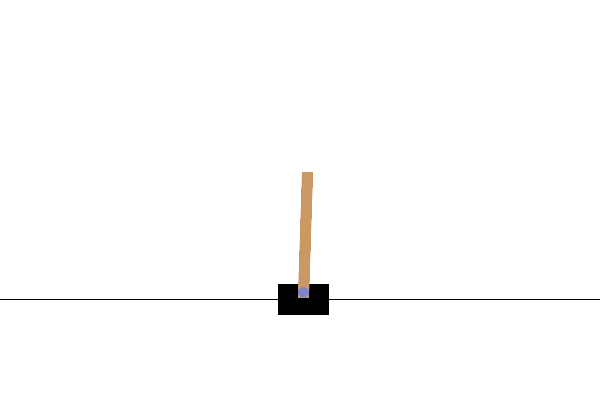

In [4]:
import imageio.v2 as imageio
from IPython.display import Image, display

imageio.mimsave("agent_aleatoire.gif", frames_alea, fps=30)
print("GIF sauvegardé : agent_aleatoire.gif")
display(Image(filename="agent_aleatoire.gif"))


## 4. Comparer trois agents Stable-Baselines3

Cette partie prolonge la découverte de l'environnement. PPO, A2C et DQN sont
entraînés avec le même budget de 50 000 pas, puis évalués sur 20 épisodes. Les
réglages DQN sont adaptés à CartPole ; PPO et A2C utilisent leurs valeurs par
défaut.

Cette comparaison reste pédagogique : une étude complète demanderait plusieurs
seeds d'entraînement.


In [5]:
import time

import torch
from stable_baselines3 import A2C, DQN, PPO
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

torch.set_num_threads(1)

TIMESTEPS = 50_000
EVAL_FREQ = 2_000


class CourbeApprentissage(BaseCallback):
    """Évalue périodiquement un modèle pour construire sa courbe."""

    def __init__(self, eval_env, eval_freq, n_eval_episodes=10):
        super().__init__()
        self.eval_env = eval_env
        self.eval_freq = eval_freq
        self.n_eval_episodes = n_eval_episodes
        self.timesteps, self.moyennes, self.ecarts = [], [], []

    def _on_step(self):
        if self.n_calls % self.eval_freq == 0:
            moyenne, ecart = evaluate_policy(
                self.model,
                self.eval_env,
                n_eval_episodes=self.n_eval_episodes,
                deterministic=True,
            )
            self.timesteps.append(self.num_timesteps)
            self.moyennes.append(moyenne)
            self.ecarts.append(ecart)
        return True


constructeurs = {
    "PPO": lambda: PPO(
        "MlpPolicy", "CartPole-v1", verbose=0, seed=0, device="cpu"
    ),
    "A2C": lambda: A2C(
        "MlpPolicy", "CartPole-v1", verbose=0, seed=0, device="cpu"
    ),
    "DQN": lambda: DQN(
        "MlpPolicy",
        "CartPole-v1",
        verbose=0,
        seed=0,
        device="cpu",
        learning_rate=2.3e-3,
        batch_size=64,
        buffer_size=100_000,
        learning_starts=1_000,
        gamma=0.99,
        target_update_interval=10,
        train_freq=256,
        gradient_steps=128,
        exploration_fraction=0.16,
        exploration_final_eps=0.04,
        policy_kwargs={"net_arch": [256, 256]},
    ),
}

modeles, resultats, historiques = {}, {}, {}
for index, (nom, construire) in enumerate(constructeurs.items()):
    debut = time.perf_counter()
    modele = construire()

    env_courbe = Monitor(gym.make("CartPole-v1"))
    env_courbe.reset(seed=1_000 + index)
    courbe = CourbeApprentissage(env_courbe, eval_freq=EVAL_FREQ)
    modele.learn(total_timesteps=TIMESTEPS, callback=courbe)
    env_courbe.close()

    env_eval = Monitor(gym.make("CartPole-v1"))
    env_eval.reset(seed=10_000)
    moyenne, ecart = evaluate_policy(
        modele, env_eval, n_eval_episodes=20, deterministic=True
    )
    env_eval.close()

    modeles[nom] = modele
    resultats[nom] = (moyenne, ecart)
    historiques[nom] = (
        np.asarray(courbe.timesteps),
        np.asarray(courbe.moyennes),
        np.asarray(courbe.ecarts),
    )
    duree = time.perf_counter() - debut
    print(
        f"{nom:4s} | {TIMESTEPS} pas en {duree:5.1f}s "
        f"| récompense : {moyenne:6.1f} +/- {ecart:.1f}"
    )


PPO  | 50000 pas en  29.4s | récompense :  500.0 +/- 0.0


A2C  | 50000 pas en  30.1s | récompense :  500.0 +/- 0.0


DQN  | 50000 pas en  42.3s | récompense :  500.0 +/- 0.0


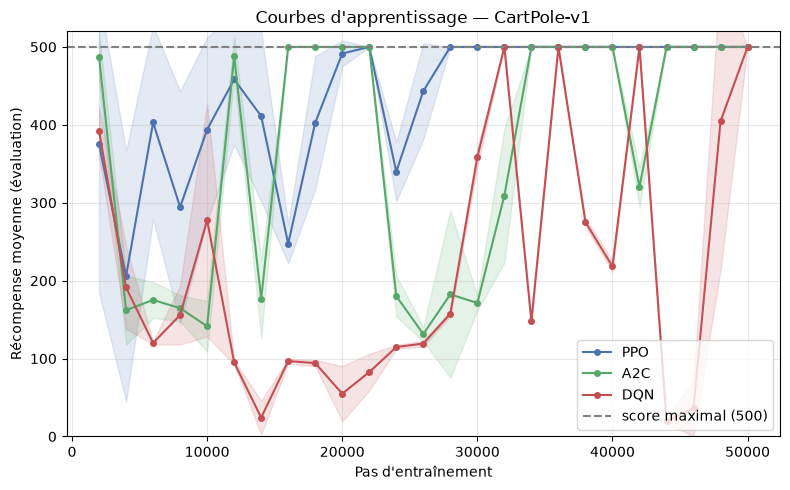

In [6]:
import matplotlib.pyplot as plt

couleurs = {"PPO": "#4C72B0", "A2C": "#55A868", "DQN": "#C44E52"}

fig, ax = plt.subplots(figsize=(8, 5))
for nom, (x, y, e) in historiques.items():
    ax.plot(x, y, marker="o", ms=4, color=couleurs[nom], label=nom)          # la courbe
    ax.fill_between(x, y - e, y + e, color=couleurs[nom], alpha=0.15)          # ± écart-type
ax.axhline(500, ls="--", color="gray", label="score maximal (500)")
ax.set_xlabel("Pas d'entraînement")
ax.set_ylabel("Récompense moyenne (évaluation)")
ax.set_title("Courbes d'apprentissage — CartPole-v1")
ax.set_ylim(0, 520)
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

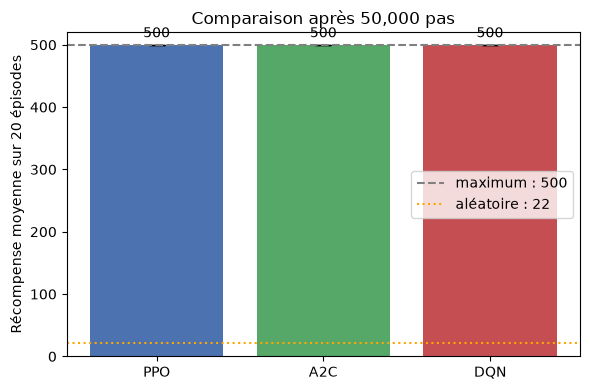

In [7]:
import matplotlib.pyplot as plt

env_aleatoire = gym.make("CartPole-v1")
scores_aleatoires = []
for episode in range(20):
    observation, _ = env_aleatoire.reset(seed=20_000 + episode)
    env_aleatoire.action_space.seed(20_000 + episode)
    terminated = truncated = False
    score = 0.0
    while not (terminated or truncated):
        action = env_aleatoire.action_space.sample()
        observation, reward, terminated, truncated, _ = env_aleatoire.step(action)
        score += reward
    scores_aleatoires.append(score)
env_aleatoire.close()

baseline_aleatoire = np.mean(scores_aleatoires)
noms = list(resultats)
moyennes = [resultats[nom][0] for nom in noms]
ecarts = [resultats[nom][1] for nom in noms]

fig, ax = plt.subplots(figsize=(6, 4))
barres = ax.bar(
    noms,
    moyennes,
    yerr=ecarts,
    capsize=6,
    color=["#4C72B0", "#55A868", "#C44E52"],
)
ax.axhline(500, ls="--", color="gray", label="maximum : 500")
ax.axhline(
    baseline_aleatoire,
    ls=":",
    color="orange",
    label=f"aléatoire : {baseline_aleatoire:.0f}",
)
ax.set_ylabel("Récompense moyenne sur 20 épisodes")
ax.set_title(f"Comparaison après {TIMESTEPS:,} pas")
ax.set_ylim(0, 520)
ax.legend()
ax.bar_label(barres, fmt="%.0f", padding=3)
plt.tight_layout()
plt.show()


## 5. Produire le GIF de l'agent retenu


Agent retenu : PPO (récompense 500)


Aléatoire : 30 pas | PPO : 500 pas


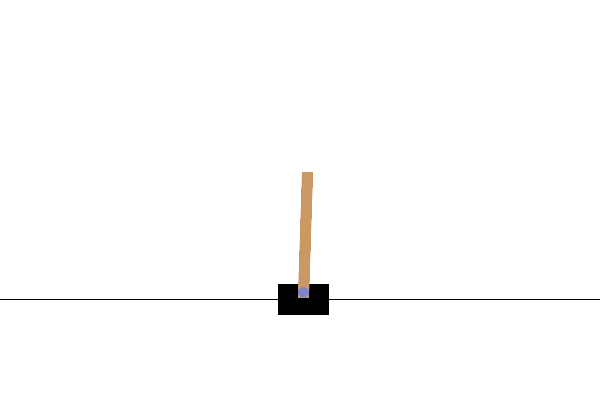

In [8]:
meilleur = max(resultats, key=lambda nom: resultats[nom][0])
print(
    f"Agent retenu : {meilleur} "
    f"(récompense {resultats[meilleur][0]:.0f})"
)

frames_entraine = collect_frames(model=modeles[meilleur], seed=42)
imageio.mimsave("agent_entraine.gif", frames_entraine, fps=30)

print(
    f"Aléatoire : {len(frames_alea) - 1} pas | "
    f"{meilleur} : {len(frames_entraine) - 1} pas"
)
display(Image(filename="agent_entraine.gif"))

for modele in modeles.values():
    modele.get_env().close()


## 6. Bilan et limites

- La politique aléatoire fournit le point de comparaison minimal.
- Les agents entraînés dépassent nettement cette baseline sur CartPole.
- Les deux GIF permettent de comparer visuellement les comportements.

Les résultats reposent sur une seule seed d'entraînement et un environnement
simple. Ils illustrent une démarche, mais ne constituent pas un classement
général des algorithmes. Les modèles restent en mémoire dans le notebook ; les
artefacts conservés sont les deux GIF.